#Import and installation of packages




In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 18.1 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

DATA_PATH_POLITIK    = Path('/content/drive/MyDrive/CSS_Analyse/reddit_politik_raw.csv')
DATA_PATH_POLITIKBRD = Path('/content/drive/MyDrive/CSS_Analyse/reddit_politikbrd_raw.csv')

print(f'Data 1: {DATA_PATH_POLITIK}')
print(f'Data 2: {DATA_PATH_POLITIKBRD}')

df_politik    = pd.read_csv(DATA_PATH_POLITIK)
df_politikbrd = pd.read_csv(DATA_PATH_POLITIKBRD)

print(f'r/politik:    {len(df_politik):,} Zeilen')
print(f'r/PolitikBRD: {len(df_politikbrd):,} Zeilen')

df = pd.concat([df_politik, df_politikbrd], ignore_index=True)

vor = len(df)
df = df.drop_duplicates(subset='id').reset_index(drop=True)
if vor != len(df):
    print(f'{vor - len(df)} Duplikate entfernt')

df['created_utc'] = pd.to_datetime(df['created_utc'], errors='coerce')
df = df.sort_values('created_utc').reset_index(drop=True)

print(f'\nKombinierter Datensatz: {len(df):,} Zeilen')
print(df['subreddit'].value_counts())
df.head()

Mounted at /content/drive
Data 1: /content/drive/MyDrive/CSS_Analyse/reddit_politik_raw.csv
Data 2: /content/drive/MyDrive/CSS_Analyse/reddit_politikbrd_raw.csv
r/politik:    398 Zeilen
r/PolitikBRD: 133 Zeilen

Kombinierter Datensatz: 531 Zeilen
subreddit
politik       398
PolitikBRD    133
Name: count, dtype: int64


,id,subreddit,title,body,text,word_count,score,num_comments,created_utc,flair
0,1hznmea,politik,"Machen die Linken nicht selbst genau das, was ...",Wurde zuletzt von einem Freund der bei der Ant...,"Machen die Linken nicht selbst genau das, was ...",48,0,60,2025-01-12,Frage
1,1hzm83e,politik,Wieso sind Leute voreingenommen? (AfD),NaN,Wieso sind Leute voreingenommen? (AfD),5,1,1,2025-01-12,Frage
2,1hzp9k4,politik,Warum ich die AfD verstehe und die Linke einfa...,Ich bin ehrlich gesagt ziemlich fertig mit dem...,Warum ich die AfD verstehe und die Linke einfa...,267,0,29,2025-01-12,Frage
3,1hzpb96,politik,"Wie passiert es eigentlich, dass Menschen ande...","Ich habe leider keinen anderen Kanal gefunden,...","Wie passiert es eigentlich, dass Menschen ande...",178,1,3,2025-01-12,Frage
4,1hzsv9v,politik,"Wann zahlen Boomer den Preis für das, was sie ...","Marode Infrastruktur, eine demographische Kata...","Wann zahlen Boomer den Preis für das, was sie ...",33,0,43,2025-01-12,Frage


In [ ]:
!pip install bertopic -q

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

df_topic = df.reset_index(drop=True).copy()
docs = df_topic['text'].tolist()

print(f'Anzahl Dokumente für Topic Modeling: {len(docs):,}')
print(f'Zeitraum: {df_topic["created_utc"].min()} bis {df_topic["created_utc"].max()}')
print(df_topic['subreddit'].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.4 MB/s eta 0:00:00
Anzahl Dokumente für Topic Modeling: 531
Zeitraum: 2025-01-12 00:00:00 bis 2025-02-22 00:00:00
subreddit
politik       398
PolitikBRD    133
Name: count, dtype: int64


#Label creation for the semi-supervised model

In [ ]:
import re

label_keywords = {
    'Scholz':  [r'\bolaf\b', r'\bscholz\b'],
    'Merz':    [r'\bfriedrich\b', r'\bmerz\b'],
    'Habeck':  [r'\brobert\b', r'\bhabeck\b'],
    'Weidel':  [r'\balice\b', r'\bweidel\b'],
    'Wirtschaft': [r'\bwirtschaft\w*', r'\binflation\w*', r'\binfrastruktur\w*'],
    'Migration': [r'\bmigration\w*', r'\bzuwanderung\w*', r'\bmigrant\w*', r'\basyl\w*'],
    'Aussenpolitik': [r'\bkrieg\w*', r'\bkonflikt\w*', r'\baußenpolitik\w*', r'\bausenpolitik\w*'],
}

label_names = list(label_keywords.keys())

def count_matches(text: str, patterns: list[str]) -> int:
    text_lower = text.lower()
    return sum(len(re.findall(p, text_lower)) for p in patterns)

def assign_label(text: str) -> str:
    counts = {label: count_matches(text, patterns) for label, patterns in label_keywords.items()}
    best_label = max(counts, key=counts.get)
    if counts[best_label] == 0:
        return 'unlabeled'
    return best_label

df_topic['label_name'] = df_topic['text'].apply(assign_label)

label_to_int = {name: i for i, name in enumerate(label_names)}
label_to_int['unlabeled'] = -1

y = df_topic['label_name'].map(label_to_int).tolist()

print(df_topic['label_name'].value_counts())
print(f'\nAnteil unlabeled: {(df_topic["label_name"] == "unlabeled").mean():.1%}')

label_name
unlabeled        343
Migration         52
Wirtschaft        51
Merz              26
Aussenpolitik     24
Scholz            14
Habeck            12
Weidel             9
Name: count, dtype: int64

Anteil unlabeled: 64.6%


#Embedding

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True,
    batch_size=64
)

print(f'Embedding-Shape: {embeddings.shape}')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Embedding-Shape: (531, 384)


#Adding stopwords

In [ ]:
!pip install spacy -q
!python -m spacy download de_core_news_sm -q

import nltk
from nltk.corpus import stopwords
import spacy

nltk.download('stopwords', quiet=True)

nltk_stopwords = set(stopwords.words('german'))

nlp = spacy.load('de_core_news_sm')
spacy_stopwords = nlp.Defaults.stop_words

custom_stopwords = {
    'https', 'http', 'www', 'com', 'org', 'net', 'de',
    'amp', 'html', 'href', 'reddit', 'redd', 'imgur',
    'jpg', 'png', 'gif', 'url'
}

german_stopwords = list(nltk_stopwords | spacy_stopwords | custom_stopwords)

print(f'NLTK Stopwords:    {len(nltk_stopwords)}')
print(f'spaCy Stopwords:   {len(spacy_stopwords)}')
print(f'Custom Stopwords:  {len(custom_stopwords)}')
print(f'Kombiniert:        {len(german_stopwords)}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 34.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
NLTK Stopwords:    232
spaCy Stopwords:   543
Custom Stopwords:  17
Kombiniert:        584


#Model creation

In [ ]:
import numpy as np

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

german_stopwords = stopwords.words('german')
vectorizer_model = CountVectorizer(stop_words=german_stopwords, ngram_range=(1, 2))

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)

y_array = np.array(y)

topics, probs = topic_model.fit_transform(docs, embeddings=embeddings, y=y_array)

print(f'Anzahl gefundener Topics (ohne Outlier -1): {len(set(topics)) - (1 if -1 in topics else 0)}')
print(topic_model.get_topic_info().head(20))

2026-09-16 14:42:55,312 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-16 14:43:53,407 - BERTopic - Dimensionality - Completed ✓
2026-09-16 14:43:53,414 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-16 14:43:53,461 - BERTopic - Cluster - Completed ✓
2026-09-16 14:43:53,469 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-16 14:43:54,275 - BERTopic - Representation - Completed ✓


Anzahl gefundener Topics (ohne Outlier -1): 23
    Topic  Count                                               Name  \
0      -1    146                          -1_https_de_https www_www   
1       0    109                         0_afd_menschen_warum_links   
2       1     22                   1_wahlkreis_umfragen_wählen_gibt   
3       2     22                  2_deutschland_politik_wer_zeitung   
4       3     21                     3_grünen_koalition_grüne_union   
5       4     20                           4_cdu_abstimmung_csu_afd   
6       5     15                                5_https_de_mrd_html   
7       6     15                                6_spd_fdp_afd_immer   
8       7     14                        7_musk_trump_elon_elon musk   
9       8     14                  8_merz_merkel_mehr_friedrich merz   
10      9     13          9_wahlentscheidung_partei_fragen_parteien   
11     10     12                    10_politik_politiker_gerade_tit   
12     11     12              

#Print existing Topics

In [ ]:
topic_info = topic_model.get_topic_info()
print(f'Anzahl Topics (inkl. Outlier -1): {len(topic_info)}')
print(topic_info)

for topic_id in topic_info['Topic']:
    if topic_id == -1:
        continue
    words = topic_model.get_topic(topic_id)
    top_words = ', '.join([w for w, _ in words[:10]])
    print(f'Topic {topic_id} ({topic_info[topic_info["Topic"] == topic_id]["Count"].values[0]} Docs): {top_words}')

example_topic_id = 0
repr_docs = topic_model.get_representative_docs(example_topic_id)
for doc in repr_docs[:3]:
    print(f'\n--- Beispiel Topic {example_topic_id} ---')
    print(doc[:300])

Anzahl Topics (inkl. Outlier -1): 24
    Topic  Count                                               Name  \
0      -1    146                          -1_https_de_https www_www   
1       0    109                         0_afd_menschen_warum_links   
2       1     22                   1_wahlkreis_umfragen_wählen_gibt   
3       2     22                  2_deutschland_politik_wer_zeitung   
4       3     21                     3_grünen_koalition_grüne_union   
5       4     20                           4_cdu_abstimmung_csu_afd   
6       5     15                                5_https_de_mrd_html   
7       6     15                                6_spd_fdp_afd_immer   
8       7     14                        7_musk_trump_elon_elon musk   
9       8     14                  8_merz_merkel_mehr_friedrich merz   
10      9     13          9_wahlentscheidung_partei_fragen_parteien   
11     10     12                    10_politik_politiker_gerade_tit   
12     11     12                      11

#Topics x Labels

In [ ]:
df_topic['bertopic_topic'] = topics

candidate_labels = {'Scholz', 'Merz', 'Habeck', 'Weidel'}
issue_labels = {'Wirtschaft', 'Migration', 'Aussenpolitik'}

def orientation(label_name: str) -> str:
    if label_name in candidate_labels:
        return 'candidate-oriented'
    elif label_name in issue_labels:
        return 'issue-oriented'
    return 'unlabeled'

df_topic['orientation'] = df_topic['label_name'].apply(orientation)

print('── Verteilung candidate- vs. issue-oriented ──')
print(df_topic['orientation'].value_counts())
print(f'\n{df_topic["orientation"].value_counts(normalize=True).round(3) * 100}')

crosstab = pd.crosstab(df_topic['bertopic_topic'], df_topic['label_name'])
print('\n── Kreuztabelle: BERTopic-Topic × Label ──')
print(crosstab)

crosstab_orientation = pd.crosstab(df_topic['bertopic_topic'], df_topic['orientation'])
print('\n── Kreuztabelle: BERTopic-Topic × Orientierung ──')
print(crosstab_orientation)

print('\n── Orientierung nach Subreddit ──')
print(pd.crosstab(df_topic['subreddit'], df_topic['orientation'], normalize='index').round(3) * 100)

── Verteilung candidate- vs. issue-oriented ──
orientation
unlabeled             343
issue-oriented        127
candidate-oriented     61
Name: count, dtype: int64

orientation
unlabeled             64.6
issue-oriented        23.9
candidate-oriented    11.5
Name: proportion, dtype: float64

── Kreuztabelle: BERTopic-Topic × Label ──
label_name      Aussenpolitik  Habeck  Merz  Migration  Scholz  Weidel  \
bertopic_topic                                                           
-1                         11       7     6          7       5       2   
 0                          2       1     2         39       0       5   
 1                          0       0     0          0       0       0   
 2                          0       1     0          0       1       0   
 3                          0       3     0          3       0       0   
 4                          0       0     3          0       1       0   
 5                          0       0     0          0       0       0   


#Visualisation of the timeline

20it [00:07,  2.65it/s]


    Topic                                              Words  Frequency  \
0      -1  wirtschaft, nl, deutsche, deutsche wirtschaft,...          4   
1       0               afd, menschen, scheint, links, linke          6   
2       5  warum schuldenbremse, schuldenbremse, schulden...          1   
3      12  forschungsstudie, fragebogen, reels, instagram...          2   
4      13   ard de, https ard, rpolitik, ard, bundestagswahl          1   
5      14    innen, einführung, bürger innen, the, maßnahmen          1   
6      15  politischer podcast, dresdner politischer, dre...          1   
7      18  vorgezogen, vorgezogen neuwahlen, neuwahlen, b...          1   
8      20  boomer, fatale migrationspolitik, zahlen boome...          1   
9       0  afd, warum, warum afd, verschwiegen, afd recht...          2   
10      1        wählt, 15, fällt wählt, sprich ende, 30 cdu          1   
11      2  demnächst anfangen, beschäftigen meinung, wahl...          1   
12      3          grünen

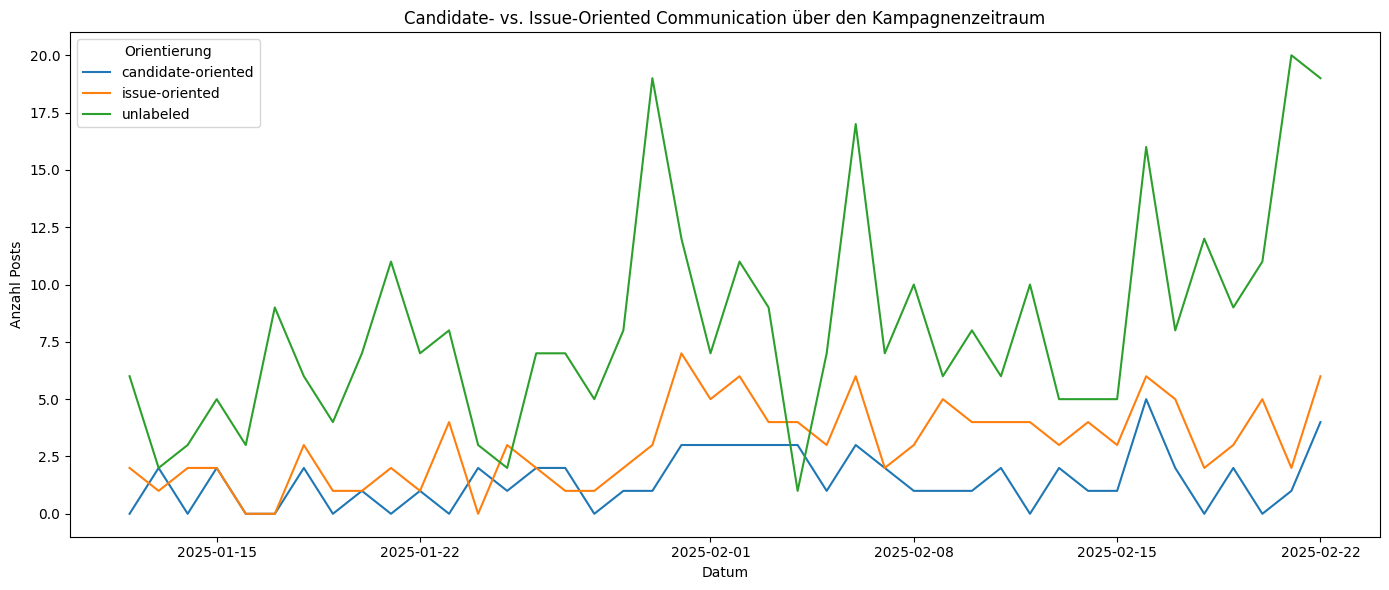

In [ ]:
import matplotlib.pyplot as plt

timestamps = df_topic['created_utc'].tolist()

topics_over_time = topic_model.topics_over_time(
    docs,
    timestamps,
    nr_bins=20
)

print(topics_over_time.head(20))

fig_time = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=10)
fig_time.show()

df_topic['created_date'] = pd.to_datetime(df_topic['created_utc']).dt.date
orientation_over_time = (
    df_topic.groupby(['created_date', 'orientation'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
orientation_over_time.plot(ax=ax)
ax.set_title('Candidate- vs. Issue-Oriented Communication über den Kampagnenzeitraum')
ax.set_xlabel('Datum')
ax.set_ylabel('Anzahl Posts')
ax.legend(title='Orientierung')
plt.tight_layout()
plt.show()

#Visualisation barchart and wordclouds

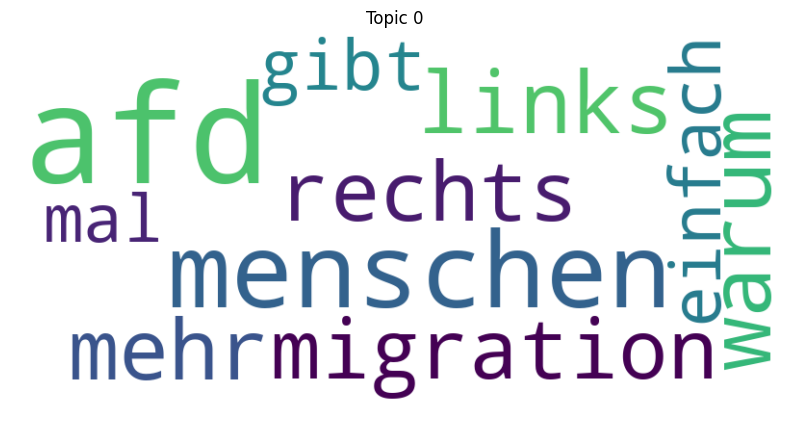

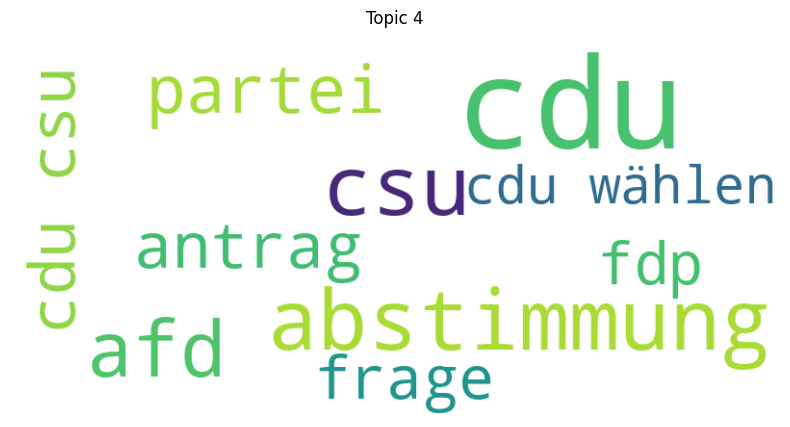

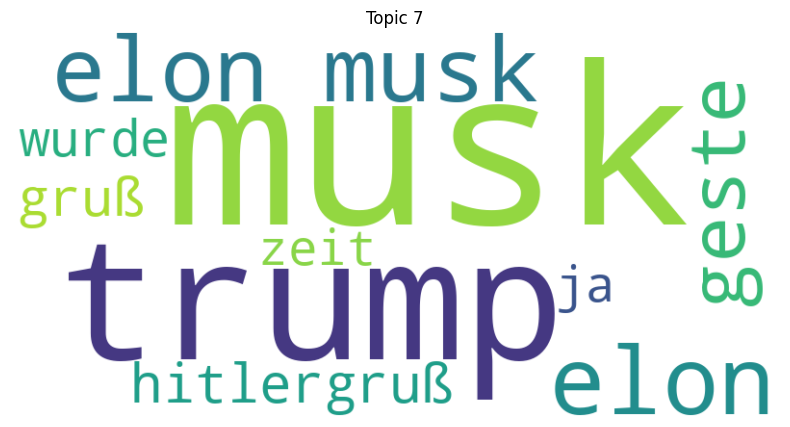

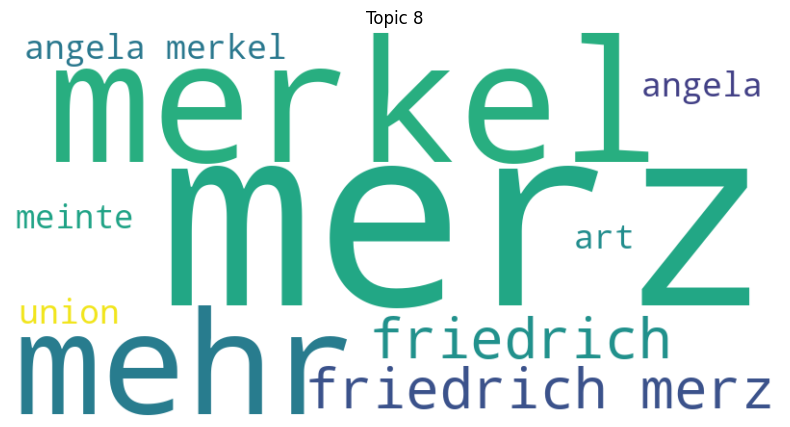

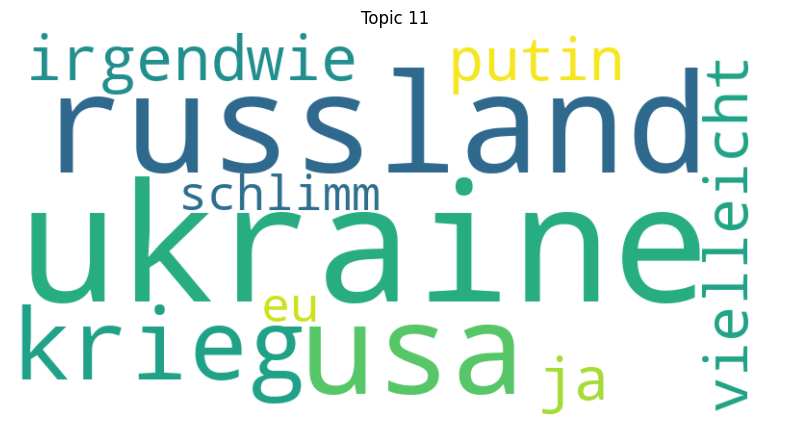

In [ ]:
import matplotlib.pyplot as plt

fig_barchart = topic_model.visualize_barchart(top_n_topics=23, n_words=8)
fig_barchart.show()

from wordcloud import WordCloud

def plot_wordcloud(topic_model, topic_id):
    word_freq = dict(topic_model.get_topic(topic_id))
    wc = WordCloud(background_color='white', width=800, height=400).generate_from_frequencies(word_freq)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Topic {topic_id}')
    plt.show()
plot_wordcloud(topic_model, 0)
plot_wordcloud(topic_model, 4)
plot_wordcloud(topic_model, 7)
plot_wordcloud(topic_model, 8)
plot_wordcloud(topic_model, 11)

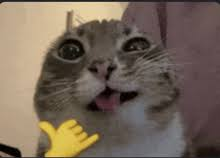
#us after submitting this paper